# Character Recognition using Multilayer Perceptron (MLP)

## Overview
This notebook implements a comprehensive character recognition system using a Multilayer Perceptron neural network with proper ML workflow including:
- Data Loading and Exploration
- Data Preprocessing and Feature Engineering
- Train/Test/Validation Split
- Model Building
- Training and Validation
- Evaluation and Performance Metrics
- Predictions on New Data

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import sklearn

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

✓ All libraries imported successfully!
NumPy version: 2.3.1
Pandas version: 2.3.0
Scikit-learn version: 1.7.2


## Step 1: Data Loading and Exploration

In [5]:
# Load dataset from folder structure (data2)
import os

# Dataset paths
data_dir = '../data/character/data2'
training_dir = os.path.join(data_dir, 'training_data')
testing_dir = os.path.join(data_dir, 'testing_data')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Data directory: {data_dir}")
print(f"Training data path: {training_dir}")
print(f"Testing data path: {testing_dir}")

# Get list of character classes
classes = sorted([d for d in os.listdir(training_dir) if os.path.isdir(os.path.join(training_dir, d))])
print(f"\nCharacter classes found: {len(classes)}")
print(f"Classes: {classes}")

# Count samples per class
print(f"\nSamples per class (training):")
class_counts = {}
for char_class in classes:
    class_dir = os.path.join(training_dir, char_class)
    count = len([f for f in os.listdir(class_dir) if f.endswith('.png')])
    class_counts[char_class] = count
    print(f"  Class '{char_class}': {count} images")

print(f"\nTotal training samples: {sum(class_counts.values())}")

DATASET OVERVIEW
Data directory: ../data/character/data2
Training data path: ../data/character/data2\training_data
Testing data path: ../data/character/data2\testing_data

Character classes found: 36
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Samples per class (training):
  Class '0': 573 images
  Class '1': 573 images
  Class '2': 573 images
  Class '3': 573 images
  Class '4': 573 images
  Class '5': 573 images
  Class '6': 573 images
  Class '7': 573 images
  Class '8': 573 images
  Class '9': 573 images
  Class 'A': 573 images
  Class 'B': 573 images
  Class 'C': 573 images
  Class 'D': 573 images
  Class 'E': 573 images
  Class 'F': 573 images
  Class 'G': 573 images
  Class 'H': 573 images
  Class 'I': 573 images
  Class 'J': 573 images
  Class 'K': 573 images
  Class 'L': 573 images
  Class 'M': 573 images
  Class 'N': 573 images
  C

In [6]:
# Load images from folder structure
def load_images_from_folders(data_dir, classes, sample_size=None, target_size=(16, 16)):
    """Load images from folder structure organized by class"""
    images = []
    labels = []
    failed_count = 0
    
    for char_class in classes:
        class_dir = os.path.join(data_dir, char_class)
        image_files = [f for f in os.listdir(class_dir) if f.endswith('.png')]
        
        if sample_size:
            import random
            image_files = random.sample(image_files, min(sample_size // len(classes), len(image_files)))
        
        for img_file in image_files:
            try:
                img_path = os.path.join(class_dir, img_file)
                img = Image.open(img_path).convert('L')
                # Resize to consistent size
                img = img.resize(target_size, Image.Resampling.LANCZOS)
                img_array = np.array(img, dtype=np.float32).flatten()
                
                images.append(img_array)
                labels.append(char_class)
            except Exception as e:
                failed_count += 1
                if failed_count <= 5:
                    print(f"Error loading {img_path}: {str(e)}")
    
    print(f"\n✓ Successfully loaded {len(images)} images")
    print(f"✗ Failed to load {failed_count} images")
    
    return np.array(images), np.array(labels)

# Load sample of images first
print("Loading sample of images...")
X_sample, y_sample = load_images_from_folders(training_dir, classes, sample_size=500)

print(f"\nImage Array Shape: {X_sample.shape}")
print(f"Label Array Shape: {y_sample.shape}")
print(f"Unique labels: {np.unique(y_sample)}")
print(f"Number of classes: {len(np.unique(y_sample))}")

Loading sample of images...

✓ Successfully loaded 468 images
✗ Failed to load 0 images

Image Array Shape: (468, 256)
Label Array Shape: (468,)
Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Number of classes: 36


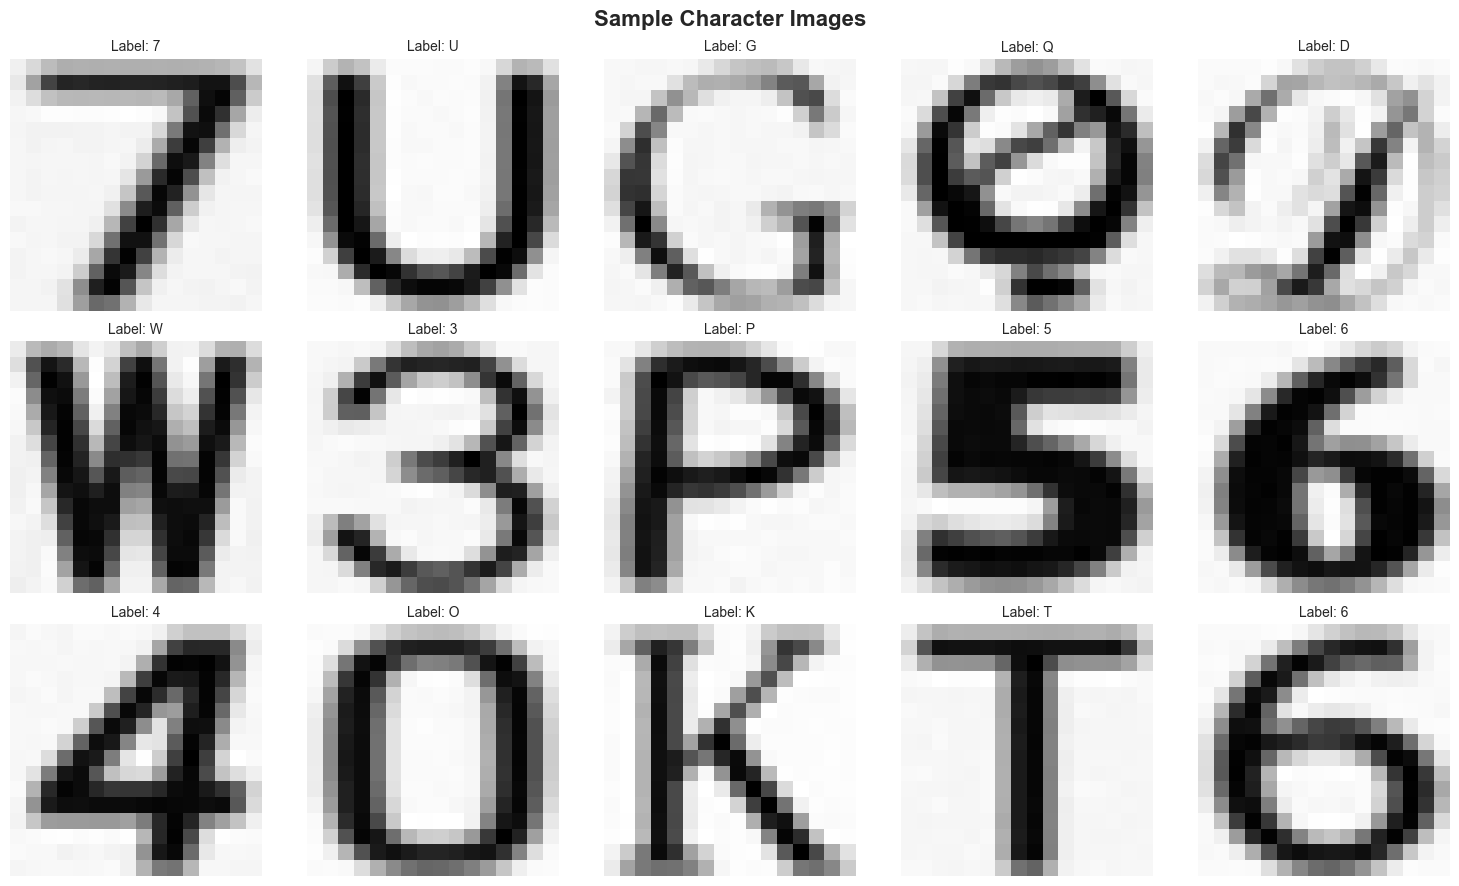

In [7]:
# Visualize sample images from folder structure
import random

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Character Images', fontsize=16, fontweight='bold')

# Randomly select 15 images from the loaded sample
num_display = 15
if len(X_sample) >= num_display:
    sample_indices = random.sample(range(len(X_sample)), num_display)
    
    for plot_idx, data_idx in enumerate(sample_indices):
        ax = axes[plot_idx // 5, plot_idx % 5]
        
        # Reshape the flattened array back to image
        img_size = int(np.sqrt(X_sample[data_idx].shape[0]))
        img_display = X_sample[data_idx].reshape(img_size, img_size)
        
        ax.imshow(img_display, cmap='gray')
        ax.set_title(f"Label: {y_sample[data_idx]}", fontsize=10)
        ax.axis('off')
else:
    print(f"Not enough samples loaded ({len(X_sample)} < {num_display})")

plt.tight_layout()
plt.show()

## Step 2: Load Full Dataset and Preprocessing

In [8]:
# Load full dataset and reduce dimensionality with IncrementalPCA
from sklearn.decomposition import IncrementalPCA

print("Loading full dataset from folders and fitting IncrementalPCA...")
n_components = 64
batch_size = 64
target_size = (16, 16)  # Consistent image size
print(f"Using n_components={n_components}, batch_size={batch_size}")
print(f"Resizing images to: {target_size}")

# Collect all image paths and labels
all_image_paths = []
all_labels = []
for char_class in classes:
    class_dir = os.path.join(training_dir, char_class)
    image_files = sorted([f for f in os.listdir(class_dir) if f.endswith('.png')])
    for img_file in image_files:
        all_image_paths.append(os.path.join(class_dir, img_file))
        all_labels.append(char_class)

y_full = np.array(all_labels)
num_samples = len(all_image_paths)

print(f"Total samples: {num_samples}")

# Load and fit PCA incrementally
pca = IncrementalPCA(n_components=n_components, batch_size=batch_size)

for start in range(0, num_samples, batch_size):
    end = min(start + batch_size, num_samples)
    X_batch = []
    for img_path in all_image_paths[start:end]:
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize(target_size, Image.Resampling.LANCZOS)
            img_array = np.array(img, dtype=np.float32).flatten()
            img_array /= 255.0
            X_batch.append(img_array)
        except Exception as e:
            # If error, add a blank image
            X_batch.append(np.zeros(target_size[0] * target_size[1], dtype=np.float32))
    if X_batch:
        pca.partial_fit(np.array(X_batch))
    if end % 500 == 0 or end == num_samples:
        print(f"  PCA fit: {end}/{num_samples}")

# Transform all data
X_reduced = np.zeros((num_samples, n_components), dtype=np.float32)
for start in range(0, num_samples, batch_size):
    end = min(start + batch_size, num_samples)
    X_batch = []
    for img_path in all_image_paths[start:end]:
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize(target_size, Image.Resampling.LANCZOS)
            img_array = np.array(img, dtype=np.float32).flatten()
            img_array /= 255.0
            X_batch.append(img_array)
        except Exception as e:
            # If error, add a blank image
            X_batch.append(np.zeros(target_size[0] * target_size[1], dtype=np.float32))
    if X_batch:
        X_reduced[start:end] = pca.transform(np.array(X_batch)).astype(np.float32)
    if end % 500 == 0 or end == num_samples:
        print(f"  PCA transform: {end}/{num_samples}")

X_full = X_reduced
print("\nPCA complete")
print(f"  Total samples: {X_full.shape[0]}")
print(f"  Features per sample: {X_full.shape[1]}")
print(f"  Unique classes: {len(np.unique(y_full))}")

Loading full dataset from folders and fitting IncrementalPCA...
Using n_components=64, batch_size=64
Resizing images to: (16, 16)
Total samples: 20628
  PCA fit: 8000/20628
  PCA fit: 16000/20628
  PCA fit: 20628/20628
  PCA transform: 8000/20628
  PCA transform: 16000/20628
  PCA transform: 20628/20628

PCA complete
  Total samples: 20628
  Features per sample: 64
  Unique classes: 36


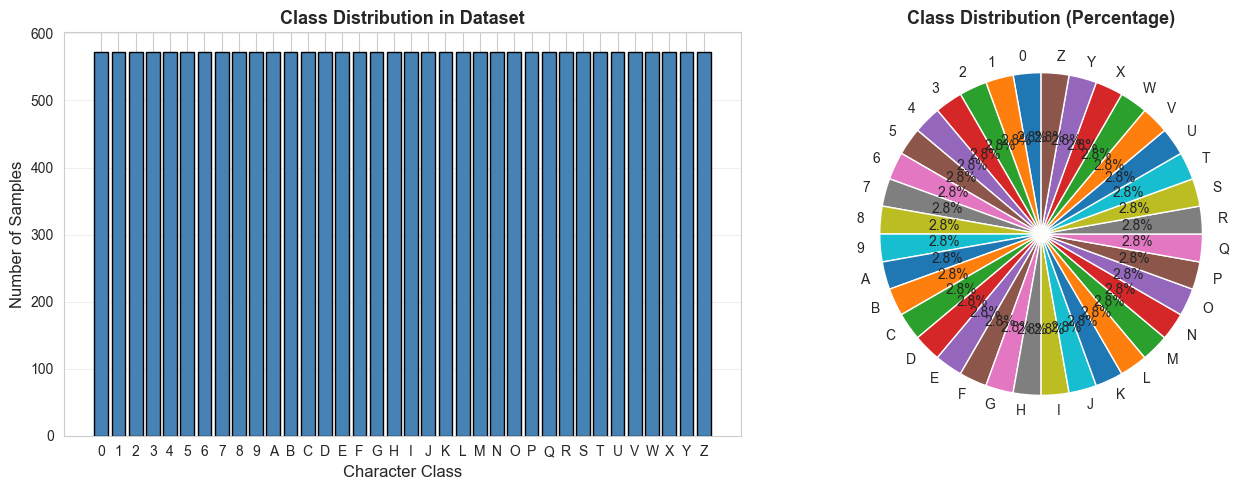

In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
unique_labels, class_counts = np.unique(y_full, return_counts=True)
axes[0].bar(unique_labels, class_counts, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Character Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Class Distribution in Dataset', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=unique_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Standardization is moved after split (in Step 3) to prevent data leakage
print("Skipping global standardization here.")
print("Features will be standardized in Step 3 using train-only fit.")

Skipping global standardization here.
Features will be standardized in Step 3 using train-only fit.


## Step 3: Train-Validation-Test Split

In [11]:
# Convert labels to numeric encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

print("Label encoding:")
print(f"  Original labels: {np.unique(y_full)}")
print(f"  Encoded labels: {np.unique(y_encoded)}")
print(f"  Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"    {label} -> {i}")

# Split data: 70% train, 15% validation, 15% test
print("\n" + "-" * 60)
print("Splitting data into train, validation, and test sets...")
print("-" * 60)

idx_all = np.arange(len(X_full))

X_train_raw, X_temp_raw, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X_full, y_encoded, idx_all, test_size=0.30, random_state=42, stratify=y_encoded
)

X_val_raw, X_test_raw, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp_raw, y_temp, idx_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Standardize using ONLY training data to avoid data leakage
print("\nStandardizing features (fit on train only)...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X_full)*100:.2f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_full)*100:.2f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X_full)*100:.2f}%)")
print(f"\nTotal: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} samples")

print("\nClass distribution check:")
for label_idx in np.unique(y_encoded):
    train_pct = np.sum(y_train == label_idx) / len(y_train) * 100
    val_pct = np.sum(y_val == label_idx) / len(y_val) * 100
    test_pct = np.sum(y_test == label_idx) / len(y_test) * 100
    orig_label = le.classes_[label_idx]
    if label_idx % 10 == 0:
        print(f"  Class {orig_label} ({label_idx}): Train={train_pct:.1f}%, Val={val_pct:.1f}%, Test={test_pct:.1f}%")

Label encoding:
  Original labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
  Encoded labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35]
  Label mapping:
    0 -> 0
    1 -> 1
    2 -> 2
    3 -> 3
    4 -> 4
    5 -> 5
    6 -> 6
    7 -> 7
    8 -> 8
    9 -> 9
    A -> 10
    B -> 11
    C -> 12
    D -> 13
    E -> 14
    F -> 15
    G -> 16
    H -> 17
    I -> 18
    J -> 19
    K -> 20
    L -> 21
    M -> 22
    N -> 23
    O -> 24
    P -> 25
    Q -> 26
    R -> 27
    S -> 28
    T -> 29
    U -> 30
    V -> 31
    W -> 32
    X -> 33
    Y -> 34
    Z -> 35

------------------------------------------------------------
Splitting data into train, validation, and test sets...
------------------------------------------------------------

Standardizing features (fit on train only)...
Training set:   14439 sa

## Step 4: Multilayer Perceptron Model Building

In [12]:
# Build Multilayer Perceptron Model
print("Building Multilayer Perceptron Model...")
print("=" * 60)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),    # Keep architecture unchanged
    max_iter=500,                          # Allow enough iterations to converge
    batch_size=32,                         # Smaller batch often improves generalization
    learning_rate='adaptive',              # Reduce LR automatically when plateauing
    learning_rate_init=0.0005,             # More stable starting LR
    activation='relu',                     # ReLU activation function
    solver='adam',                         # Adam optimizer
    alpha=1e-4,                            # Stronger L2 regularization
    early_stopping=True,                   # Stop before overfitting
    validation_fraction=0.1,               # Internal split from training set
    n_iter_no_change=20,                   # Patience for early stopping
    random_state=42,                       # For reproducibility
    verbose=1                              # Print progress
)

print("\nModel Configuration:")
print(f"  Hidden layers: {mlp_model.hidden_layer_sizes}")
print(f"  Activation function: {mlp_model.activation}")
print(f"  Solver: {mlp_model.solver}")
print(f"  Learning rate: {mlp_model.learning_rate_init}")
print(f"  Maximum iterations: {mlp_model.max_iter}")
print(f"  Early stopping: {mlp_model.early_stopping}")
print("=" * 60)

Building Multilayer Perceptron Model...

Model Configuration:
  Hidden layers: (512, 256, 128)
  Activation function: relu
  Solver: adam
  Learning rate: 0.0005
  Maximum iterations: 500
  Early stopping: True


## Step 5: Model Training

In [13]:
import time

# Train the model
print("\nTraining Multilayer Perceptron Model...")
print("=" * 60)

start_time = time.time()

mlp_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"\n✓ Training completed in {training_time:.2f} seconds")
print(f"  Iterations: {mlp_model.n_iter_}")
print(f"  Loss: {mlp_model.loss_:.6f}")
print(f"  Training accuracy: {mlp_model.score(X_train, y_train):.4f}")


Training Multilayer Perceptron Model...


Iteration 1, loss = 0.81751260
Validation score: 0.937673
Iteration 2, loss = 0.19385638
Validation score: 0.949446
Iteration 3, loss = 0.11974979
Validation score: 0.953601
Iteration 4, loss = 0.08396451
Validation score: 0.945291
Iteration 5, loss = 0.05943460
Validation score: 0.947368
Iteration 6, loss = 0.05664402
Validation score: 0.952216
Iteration 7, loss = 0.03648971
Validation score: 0.952909
Iteration 8, loss = 0.03162557
Validation score: 0.954294
Iteration 9, loss = 0.02984060
Validation score: 0.954986
Iteration 10, loss = 0.03164407
Validation score: 0.951524
Iteration 11, loss = 0.04957822
Validation score: 0.943906
Iteration 12, loss = 0.05273188
Validation score: 0.952909
Iteration 13, loss = 0.03752879
Validation score: 0.958449
Iteration 14, loss = 0.02570742
Validation score: 0.961219
Iteration 15, loss = 0.02243524
Validation score: 0.955679
Iteration 16, loss = 0.02737752
Validation score: 0.948061
Iteration 17, loss = 0.03379733
Validation score: 0.945291
Iterat

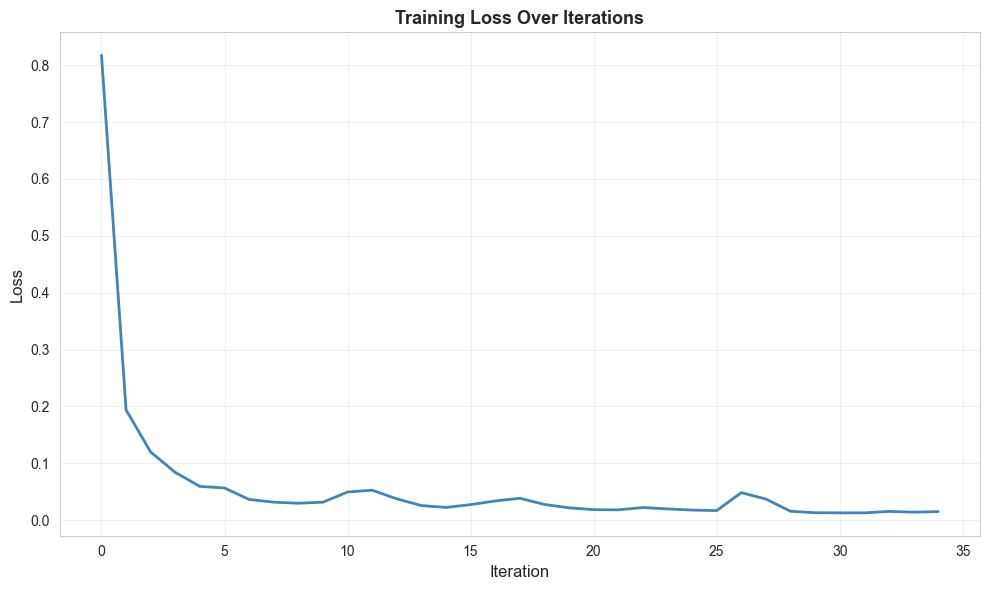

In [14]:
# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(mlp_model.loss_curve_, linewidth=2, color='steelblue')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Over Iterations', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Model Evaluation

In [15]:
# Make predictions
print("Making predictions on validation and test sets...")
y_train_pred = mlp_model.predict(X_train)
y_val_pred = mlp_model.predict(X_val)
y_test_pred = mlp_model.predict(X_test)

# Get prediction probabilities
y_train_pred_proba = mlp_model.predict_proba(X_train)
y_val_pred_proba = mlp_model.predict_proba(X_val)
y_test_pred_proba = mlp_model.predict_proba(X_test)

print("✓ Predictions completed")

Making predictions on validation and test sets...
✓ Predictions completed


In [16]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name=""):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{set_name} Performance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return accuracy, precision, recall, f1

print("=" * 60)
print(f"MODEL PERFORMANCE METRICS")
print("=" * 60)

train_acc, train_prec, train_rec, train_f1 = calculate_metrics(y_train, y_train_pred, "TRAINING SET")
val_acc, val_prec, val_rec, val_f1 = calculate_metrics(y_val, y_val_pred, "VALIDATION SET")
test_acc, test_prec, test_rec, test_f1 = calculate_metrics(y_test, y_test_pred, "TEST SET")

print("\n" + "=" * 60)

MODEL PERFORMANCE METRICS

TRAINING SET Performance Metrics:
  Accuracy:  0.9874
  Precision: 0.9891
  Recall:    0.9874
  F1-Score:  0.9872

VALIDATION SET Performance Metrics:
  Accuracy:  0.9525
  Precision: 0.9547
  Recall:    0.9525
  F1-Score:  0.9522

TEST SET Performance Metrics:
  Accuracy:  0.9483
  Precision: 0.9519
  Recall:    0.9483
  F1-Score:  0.9477



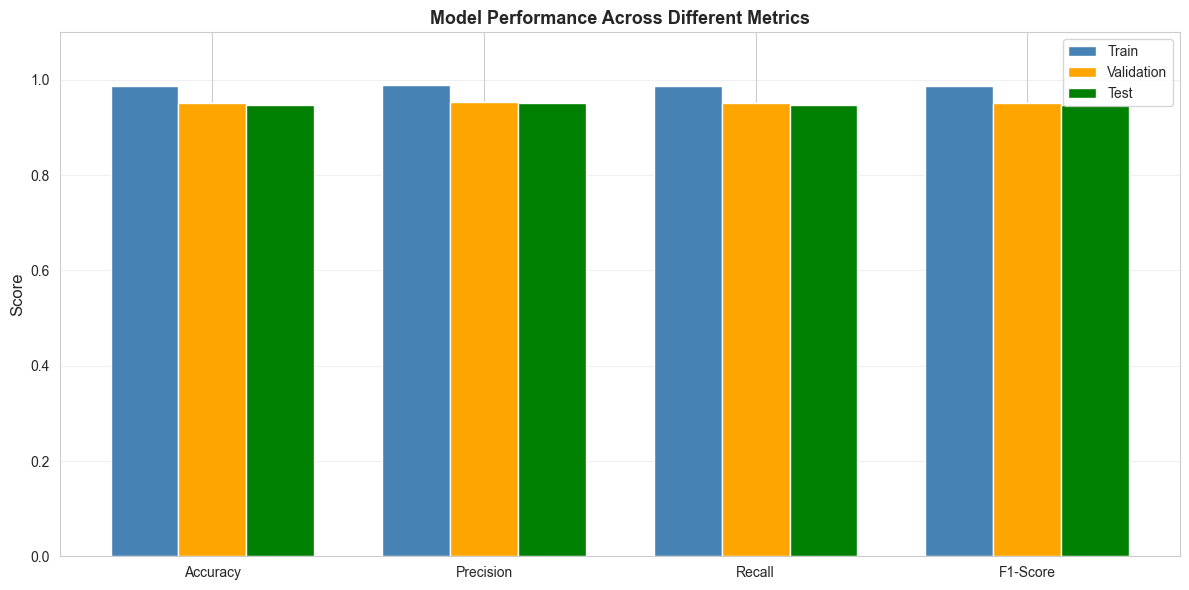

In [17]:
# Comparison plot
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Train': [train_acc, train_prec, train_rec, train_f1],
    'Validation': [val_acc, val_prec, val_rec, val_f1],
    'Test': [test_acc, test_prec, test_rec, test_f1]
}

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_data['Metric']))
width = 0.25

ax.bar(x - width, metrics_data['Train'], width, label='Train', color='steelblue')
ax.bar(x, metrics_data['Validation'], width, label='Validation', color='orange')
ax.bar(x + width, metrics_data['Test'], width, label='Test', color='green')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Across Different Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

In [18]:
# Detailed Classification Report for Test Set
print("\nDetailed Classification Report - TEST SET:")
print("=" * 60)
print(classification_report(y_test, y_test_pred, 
                          target_names=[f"Class {i}" for i in np.unique(y_test)]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix shape: {cm.shape}")


Detailed Classification Report - TEST SET:
              precision    recall  f1-score   support

     Class 0       0.60      0.88      0.72        86
     Class 1       0.99      0.94      0.96        86
     Class 2       0.99      0.99      0.99        86
     Class 3       0.98      0.99      0.98        86
     Class 4       0.99      0.97      0.98        86
     Class 5       0.98      0.95      0.96        86
     Class 6       0.98      1.00      0.99        86
     Class 7       0.97      0.99      0.98        86
     Class 8       0.98      0.95      0.96        86
     Class 9       0.93      0.99      0.96        86
    Class 10       0.92      0.97      0.94        86
    Class 11       0.92      1.00      0.96        86
    Class 12       0.98      0.98      0.98        86
    Class 13       0.91      0.99      0.95        85
    Class 14       0.99      0.99      0.99        86
    Class 15       0.94      0.99      0.97        86
    Class 16       0.96      0.95    

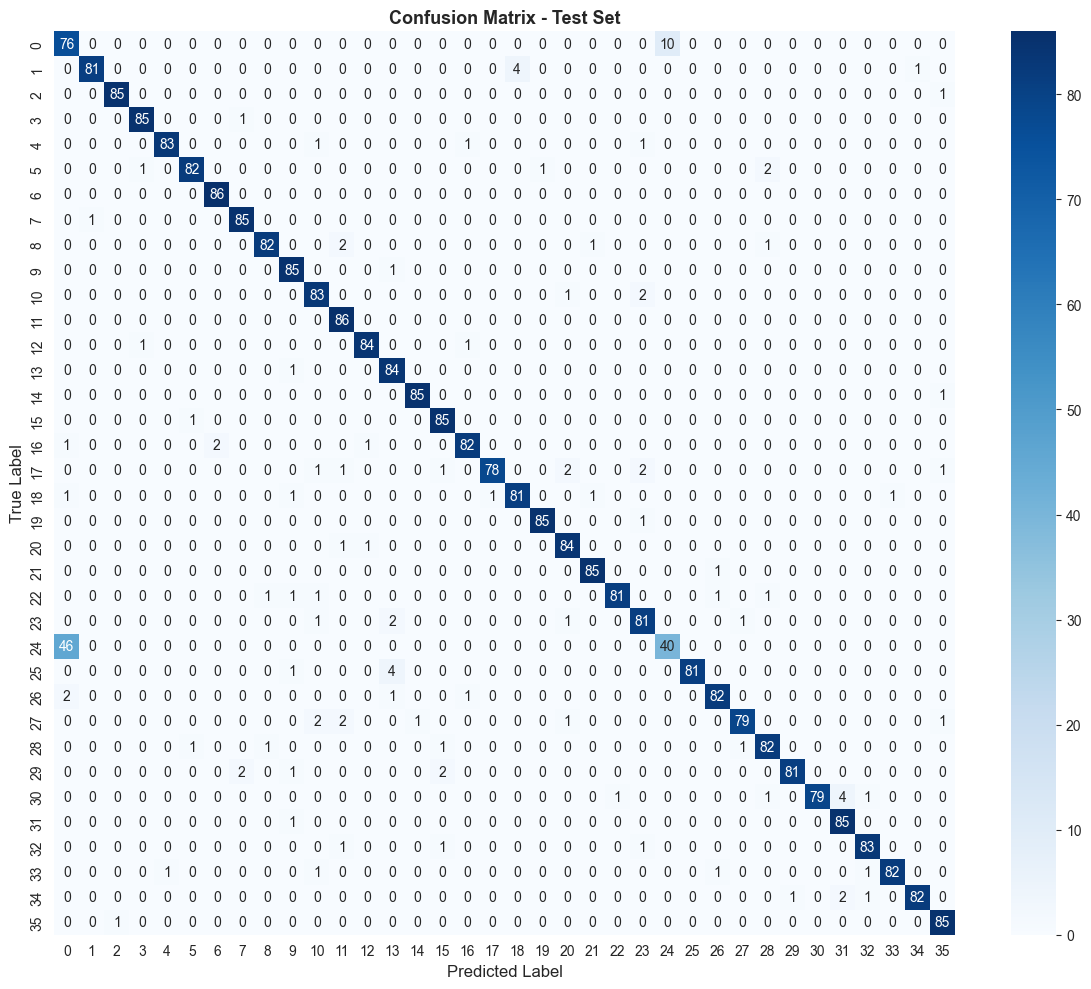

In [19]:
# Visualize Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Predictions on New Data

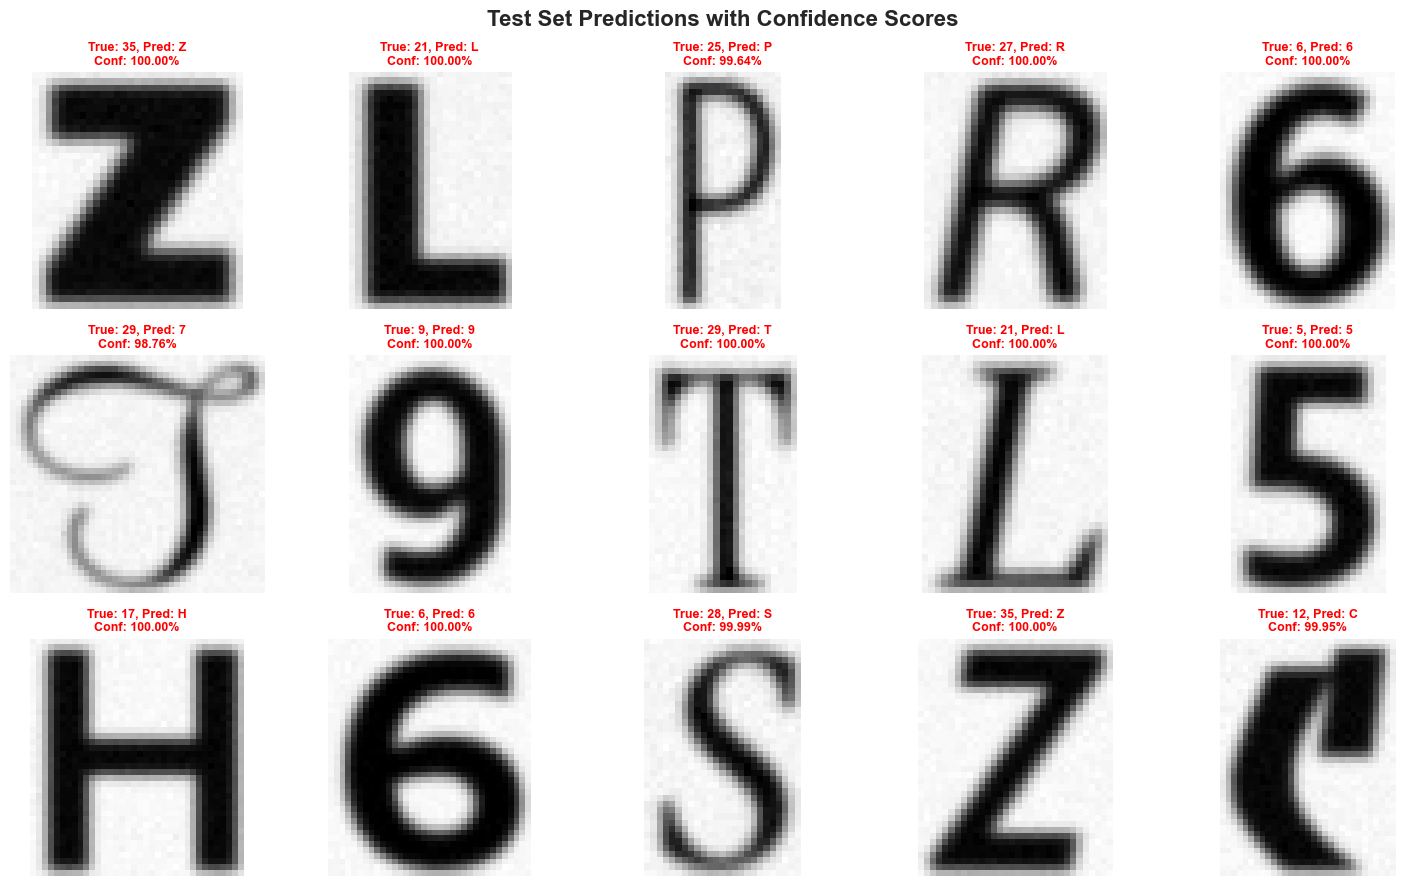

In [20]:
# Make predictions on test samples with confidence scores
num_samples = 15
test_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Test Set Predictions with Confidence Scores', fontsize=16, fontweight='bold')

for idx, test_pos in enumerate(test_indices):
    ax = axes[idx // 5, idx % 5]

    # Get the image path from our loaded sample
    data_idx = idx_test[test_pos]
    img_path = all_image_paths[data_idx]
    
    try:
        img = Image.open(img_path).convert('L')
        img_display = np.array(img)

        true_label = y_test[test_pos]
        pred_label = le.inverse_transform([y_test_pred[test_pos]])[0]
        confidence = y_test_pred_proba[test_pos].max()

        color = 'green' if true_label == pred_label else 'red'

        ax.imshow(img_display, cmap='gray')
        ax.set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2%}',
                    fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading\n{str(e)[:20]}', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

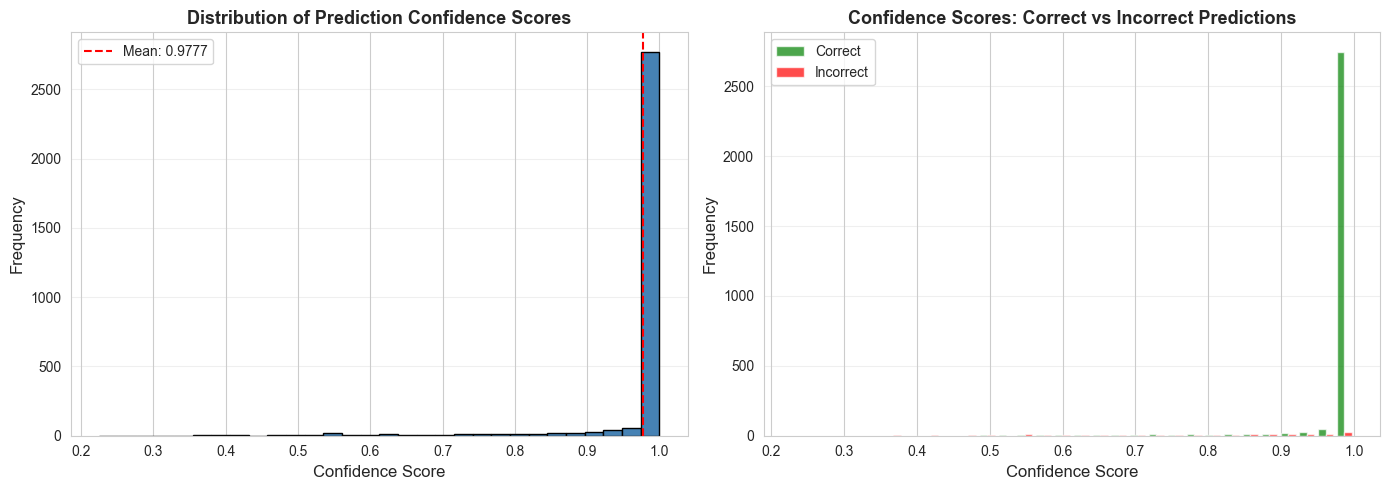


Confidence Score Statistics:
  Mean: 0.9777
  Median: 1.0000
  Min: 0.2253
  Max: 1.0000
  Std Dev: 0.0835


In [21]:
# Analyze prediction confidence distribution
confidence_scores = y_test_pred_proba.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores
axes[0].hist(confidence_scores, bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Confidence Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Confidence Scores', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(confidence_scores.mean(), color='red', linestyle='--', 
                label=f'Mean: {confidence_scores.mean():.4f}')
axes[0].legend()

# Correct vs Incorrect predictions
correct = y_test == y_test_pred
axes[1].hist([confidence_scores[correct], confidence_scores[~correct]], 
             bins=30, label=['Correct', 'Incorrect'], color=['green', 'red'], alpha=0.7)
axes[1].set_xlabel('Confidence Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Confidence Scores: Correct vs Incorrect Predictions', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConfidence Score Statistics:")
print(f"  Mean: {confidence_scores.mean():.4f}")
print(f"  Median: {np.median(confidence_scores):.4f}")
print(f"  Min: {confidence_scores.min():.4f}")
print(f"  Max: {confidence_scores.max():.4f}")
print(f"  Std Dev: {confidence_scores.std():.4f}")

## Step 8: Model Summary and Analysis

In [22]:
print("\n" + "=" * 70)
print("MULTILAYER PERCEPTRON - CHARACTER RECOGNITION MODEL SUMMARY")
print("=" * 70)

print("\n📊 DATASET INFORMATION:")
print(f"  Total samples: {len(X_full)}")
print(f"  Training samples: {len(X_train)} (70%)")
print(f"  Validation samples: {len(X_val)} (15%)")
print(f"  Test samples: {len(X_test)} (15%)")
print(f"  Features per image: {X_train.shape[1]}")
print(f"  Number of classes: {len(np.unique(y_full))}")

print("\n🧠 MODEL ARCHITECTURE:")
print(f"  Input layer: {X_train.shape[1]} neurons")
print(f"  Hidden layer 1: 512 neurons (ReLU)")
print(f"  Hidden layer 2: 256 neurons (ReLU)")
print(f"  Hidden layer 3: 128 neurons (ReLU)")
print(f"  Output layer: {len(np.unique(y_full))} neurons (Softmax)")
print(f"  Total parameters: ~{(X_train.shape[1]*512 + 512*256 + 256*128 + 128*len(np.unique(y_full)))}")

print("\n⚙️  TRAINING CONFIGURATION:")
print(f"  Optimizer: Adam")
print(f"  Loss function: Cross-entropy")
print(f"  Learning rate: {mlp_model.learning_rate_init} (adaptive)")
print(f"  Batch size: {mlp_model.batch_size}")
print(f"  Max iterations: {mlp_model.max_iter}")
print(f"  Early stopping: {mlp_model.early_stopping} (patience={mlp_model.n_iter_no_change})")
print(f"  Actual iterations: {mlp_model.n_iter_}")
print(f"  Training time: {training_time:.2f} seconds")

print("\n📈 PERFORMANCE METRICS:")
print(f"  Train Accuracy:      {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\n  Test Set F1-Score: {test_f1:.4f}")
print(f"  Test Set Precision: {test_prec:.4f}")
print(f"  Test Set Recall:    {test_rec:.4f}")

print("\n✅ OBSERVATIONS:")
potential_overfitting = train_acc - test_acc
if potential_overfitting > 0.1:
    print(f"  ⚠️  Potential overfitting detected (Train-Test diff: {potential_overfitting:.4f})")
else:
    print(f"  ✓ Model generalization appears good (Train-Test diff: {potential_overfitting:.4f})")

if val_acc >= 0.90:
    print(f"  ✓ Excellent validation performance")
elif val_acc >= 0.80:
    print(f"  ✓ Good validation performance")
else:
    print(f"  ⚠️  Validation performance could be improved")

print("\n" + "=" * 70)


MULTILAYER PERCEPTRON - CHARACTER RECOGNITION MODEL SUMMARY

📊 DATASET INFORMATION:
  Total samples: 20628
  Training samples: 14439 (70%)
  Validation samples: 3094 (15%)
  Test samples: 3095 (15%)
  Features per image: 64
  Number of classes: 36

🧠 MODEL ARCHITECTURE:
  Input layer: 64 neurons
  Hidden layer 1: 512 neurons (ReLU)
  Hidden layer 2: 256 neurons (ReLU)
  Hidden layer 3: 128 neurons (ReLU)
  Output layer: 36 neurons (Softmax)
  Total parameters: ~201216

⚙️  TRAINING CONFIGURATION:
  Optimizer: Adam
  Loss function: Cross-entropy
  Learning rate: 0.0005 (adaptive)
  Batch size: 32
  Max iterations: 500
  Early stopping: True (patience=20)
  Actual iterations: 35
  Training time: 173.73 seconds

📈 PERFORMANCE METRICS:
  Train Accuracy:      0.9874 (98.74%)
  Validation Accuracy: 0.9525 (95.25%)
  Test Accuracy:       0.9483 (94.83%)

  Test Set F1-Score: 0.9477
  Test Set Precision: 0.9519
  Test Set Recall:    0.9483

✅ OBSERVATIONS:
  ✓ Model generalization appears goo

In [23]:
# Save model bundle
import joblib

bundle = {
    'model': mlp_model,
    'pca': pca,
    'scaler': scaler,
    'label_encoder': le
}

bundle_path = 'mlp_character_recognition_bundle.pkl'
joblib.dump(bundle, bundle_path)

print(f"Model bundle saved to: {bundle_path}")

Model bundle saved to: mlp_character_recognition_bundle.pkl


## Step 9: Function for Predicting on Custom Images

In [24]:
def predict_character(image_path, model=mlp_model, return_top_k=3):
    """
    Predict character class from an image file
    
    Args:
        image_path: Path to image file
        model: Trained MLP model
        return_top_k: Return top K predictions
        
    Returns:
        Dictionary with prediction results
    """
    try:
        img = Image.open(image_path).convert('L')
        
        # Resize to the same size used during training
        target_size = (16, 16)
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        
        img_array = np.array(img, dtype=np.float32).flatten()
        img_array /= 255.0

        img_pca = pca.transform(img_array.reshape(1, -1))
        img_scaled = scaler.transform(img_pca)

        prediction = model.predict(img_scaled)[0]
        probabilities = model.predict_proba(img_scaled)[0]

        top_k_indices = np.argsort(probabilities)[-return_top_k:][::-1]
        top_k_predictions = [(le.inverse_transform([idx])[0], probabilities[idx]) for idx in top_k_indices]

        return {
            'image_path': image_path,
            'predicted_class': le.inverse_transform([prediction])[0],
            'confidence': probabilities[prediction],
            'top_k_predictions': top_k_predictions,
            'all_probabilities': probabilities
        }
    except Exception as e:
        return {'error': str(e)}